In [1]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


---
## **실습 1 - 센서 시계열 그려보기**
`한 엔진의 센서 값을 회차 순서대로 선 그래프로 보기`

shape: (1031, 10)
엔진별 회차 수:
unit_nr
1    192
2    287
3    179
4    218
5    155
Name: count, dtype: int64

2번 엔진: (287, 10)
     time_cycles      s_4
192            1  1399.71
193            2  1400.55
194            3  1398.30
195            4  1401.12
196            5  1399.49


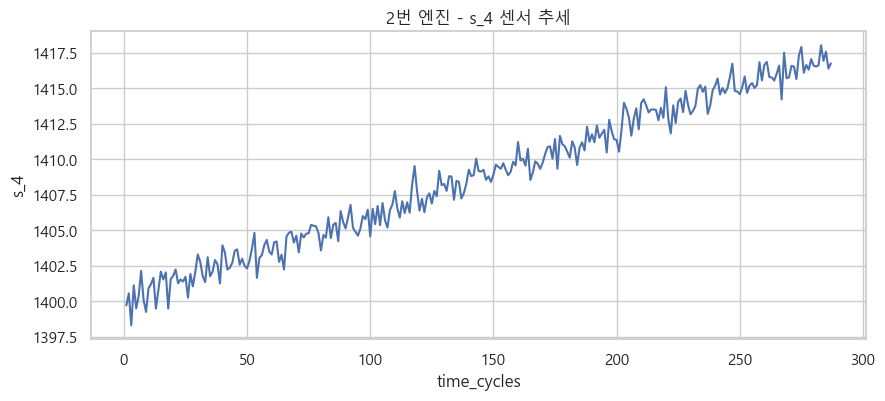

첫값 1399.71 -> 끝값 1416.77 (변화량 +17.06, 회차 상관 r=+0.989)


In [2]:
df_1 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
print("shape:", df_1.shape)
print("엔진별 회차 수:")
print(df_1["unit_nr"].value_counts().sort_index())

# 2번 엔진을 골라 회차를 가로축으로 준비
# 시계열은 순서가 생명이라 그리기 전에 반드시 정렬부터 한다
engine_1 = df_1[df_1["unit_nr"] == 2].sort_values("time_cycles")
print()
print("2번 엔진:", engine_1.shape)
print(engine_1[["time_cycles", "s_4"]].head())

# 센서 하나를 선 그래프로 그리기
# 제목, 축 이름을 붙이고 값이 오르내리는 방향 읽기
plt.figure(figsize=(10, 4))
plt.title("2번 엔진 - s_4 센서 추세")
plt.plot(engine_1["time_cycles"], engine_1["s_4"])
plt.xlabel("time_cycles")
plt.ylabel("s_4")
plt.show()

# 눈으로 본 방향을 숫자로 검산
첫값_1 = engine_1["s_4"].iloc[0]
끝값_1 = engine_1["s_4"].iloc[-1]
r_1 = engine_1["time_cycles"].corr(engine_1["s_4"])
print(f"첫값 {첫값_1:.2f} -> 끝값 {끝값_1:.2f} (변화량 {끝값_1 - 첫값_1:+.2f}, 회차 상관 r={r_1:+.3f})")

# [확인]
# 점 하나하나는 위아래로 튀지만 전체 흐름은 우상향
# r = +0.989로 회차와 거의 직선 관계라 상승 추세가 확실하다

---
## **실습 2 - 이동평균선으로 추세 보기**
`떨리는 원본 위에 매끈한 이동평균선을 겹쳐 추세 보기`

192         NaN
193         NaN
194         NaN
195         NaN
196         NaN
197         NaN
198         NaN
199         NaN
200         NaN
201    1400.189
202    1400.338
203    1400.448
Name: s_4, dtype: float64

이동평균 NaN 개수: 9 (= window - 1 = 9 )


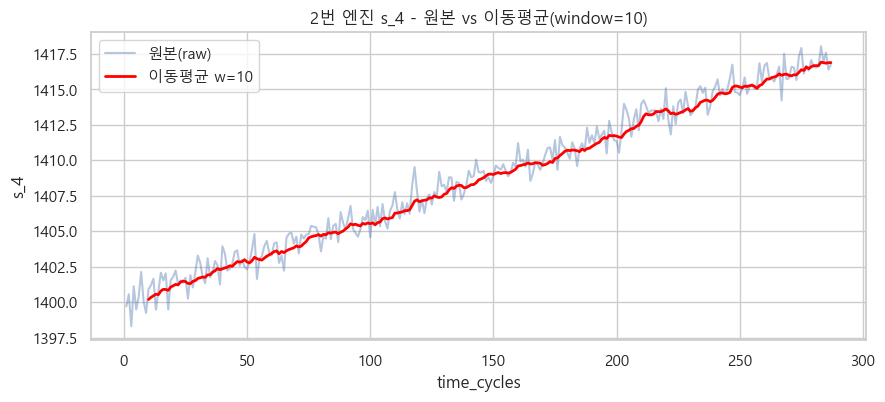


원본 표준편차     : 5.084
이동평균 표준편차 : 4.875 <- 잡음이 걸러져 값이 작아짐


In [3]:
df_2 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_2 = df_2[df_2["unit_nr"] == 2].sort_values("time_cycles")

# 창 크기 10으로 이동평균을 구하기
# rolling(window=10)은 "직전 10개를 한 묶음으로" 보는 창을 한 칸씩 밀며 계산한다
ma10_2 = engine_2["s_4"].rolling(window=10).mean()
print(ma10_2.head(12).round(3))

# 앞쪽 9개가 NaN인 이유 - 10개가 모여야 첫 평균이 나오기 때문
print()
print("이동평균 NaN 개수:", ma10_2.isna().sum(), "(= window - 1 =", 10 - 1, ")")

# 원본과 이동평균을 한 그래프에 겹쳐 그리기
# 범례를 붙이고 이동평균이 추세를 드러냄을 확인
plt.figure(figsize=(10, 4))
plt.title("2번 엔진 s_4 - 원본 vs 이동평균(window=10)")
plt.plot(engine_2["time_cycles"], engine_2["s_4"], label="원본(raw)", alpha=0.4)
plt.plot(engine_2["time_cycles"], ma10_2, label="이동평균 w=10", linewidth=2, color="red")
plt.xlabel("time_cycles")
plt.ylabel("s_4")
plt.legend()
plt.show()

# 평활 전후 흔들림 정도를 숫자로 비교
print()
print("원본 표준편차     :", round(engine_2["s_4"].std(), 3))
print("이동평균 표준편차 :", round(ma10_2.std(), 3), "<- 잡음이 걸러져 값이 작아짐")

# [확인]
# 원본은 위아래로 튀어 방향이 잘 안 보이지만, 이동평균은 매끈한 상승선이 된다
# 대신 앞쪽 9칸이 비고, 급변 시점이 뒤로 밀리는 지연(lag)이 생긴다

---
## **실습 3 - 윈도우 크기 바꿔 비교하기**
`창 크기를 바꿔 매끈함과 빈 구간의 맞교환 관찰`

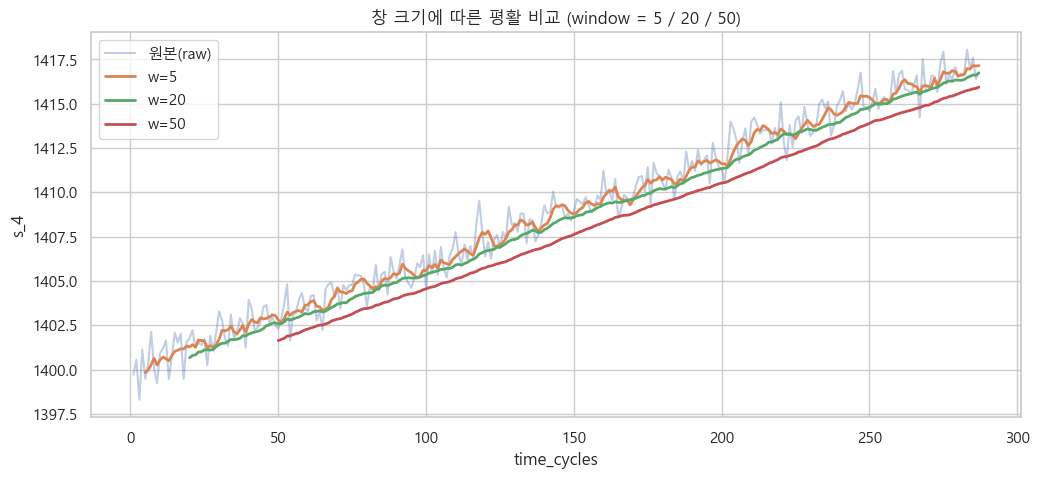

[창 크기별 빈 구간과 매끈함]
w=  5 | 앞쪽 NaN   4개 | 표준편차 4.968 | 값이 처음 나오는 회차 5
w= 20 | 앞쪽 NaN  19개 | 표준편차 4.703 | 값이 처음 나오는 회차 20
w= 50 | 앞쪽 NaN  49개 | 표준편차 4.194 | 값이 처음 나오는 회차 50


In [4]:
df_3 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_3 = df_3[df_3["unit_nr"] == 2].sort_values("time_cycles")

# 원본을 옅게 그린 뒤 세 가지 창 크기 이동평균을 겹치기
plt.figure(figsize=(12, 5))
plt.title("창 크기에 따른 평활 비교 (window = 5 / 20 / 50)")
plt.plot(engine_3["time_cycles"], engine_3["s_4"], label="원본(raw)", alpha=0.35)

for w in [5, 20, 50]:
    ma_3 = engine_3["s_4"].rolling(window=w).mean()
    plt.plot(engine_3["time_cycles"], ma_3, label=f"w={w}", linewidth=2)

plt.xlabel("time_cycles")
plt.ylabel("s_4")
plt.legend()
plt.show()

# 창이 클수록 더 매끄럽지만 앞쪽 빈 구간이 긺을 확인
print("[창 크기별 빈 구간과 매끈함]")
for w in [5, 20, 50]:
    ma_3 = engine_3["s_4"].rolling(window=w).mean()
    # first_valid_index()는 "행 인덱스"를 주므로 회차를 보려면 time_cycles에서 다시 찾아야 한다
    첫회차_3 = engine_3.loc[ma_3.first_valid_index(), "time_cycles"]
    print(f"w={w:3} | 앞쪽 NaN {ma_3.isna().sum():3}개 | 표준편차 {ma_3.std():.3f} | 값이 처음 나오는 회차 {첫회차_3}")

# [확인]
# 창이 커질수록 선은 매끄러워지지만(표준편차 감소) 앞쪽 빈 구간이 w-1만큼 길어진다
# w=50이면 287회차 중 앞 49회차를 통째로 못 쓰게 되는 맞교환

---
## **실습 4 - 여러 센서 추세 방향 비교**
`여러 센서의 이동평균을 함께 그려 방향 비교`

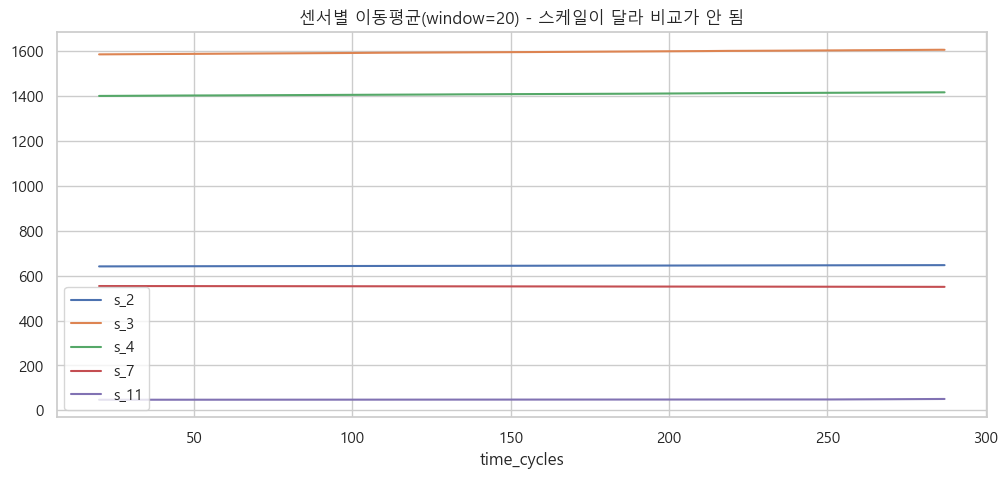

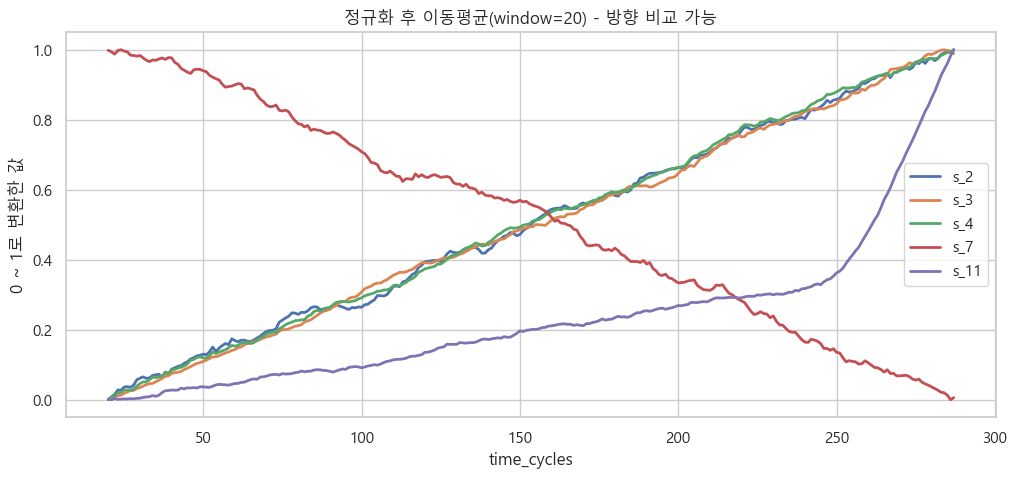

[센서별 추세 방향]
s_2      640.95 ->    646.57  r=+0.968  상승
s_3     1585.27 ->   1605.90  r=+0.988  상승
s_4     1399.71 ->   1416.77  r=+0.989  상승
s_7      554.13 ->    550.10  r=-0.967  하강
s_11      47.22 ->     51.25  r=+0.837  상승


In [5]:
df_4 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_4 = df_4[df_4["unit_nr"] == 2].sort_values("time_cycles")

sensors_4 = ["s_2", "s_3", "s_4", "s_7", "s_11"]

# 대상 센서마다 창 크기 20 이동평균을 구해 한 그래프에 겹쳐 그리기
plt.figure(figsize=(12, 5))
plt.title("센서별 이동평균(window=20) - 스케일이 달라 비교가 안 됨")
for sensor in sensors_4:
    ma_4 = engine_4[sensor].rolling(window=20).mean()
    plt.plot(engine_4["time_cycles"], ma_4, label=sensor)
plt.xlabel("time_cycles")
plt.legend()
plt.show()

# 센서마다 값의 자릿수가 달라서 한 축에 올리면 작은 센서가 눌린다
# 0~1로 정규화해서 "모양"만 남기면 방향 비교가 가능해진다
plt.figure(figsize=(12, 5))
plt.title("정규화 후 이동평균(window=20) - 방향 비교 가능")
for sensor in sensors_4:
    ma_4 = engine_4[sensor].rolling(window=20).mean()
    정규화_4 = (ma_4 - ma_4.min()) / (ma_4.max() - ma_4.min())
    plt.plot(engine_4["time_cycles"], 정규화_4, label=sensor, linewidth=2)
plt.xlabel("time_cycles")
plt.ylabel("0 ~ 1로 변환한 값")
plt.legend()
plt.show()

# 각 센서가 오르는지 내리는지 방향 판정
print("[센서별 추세 방향]")
for sensor in sensors_4:
    첫값_4 = engine_4[sensor].iloc[0]
    끝값_4 = engine_4[sensor].iloc[-1]
    r_4 = engine_4["time_cycles"].corr(engine_4[sensor])
    방향_4 = "상승" if r_4 > 0 else "하강"
    print(f"{sensor:5} {첫값_4:>9.2f} -> {끝값_4:>9.2f}  r={r_4:+.3f}  {방향_4}")

# [확인]
# s_2, s_3, s_4, s_11은 상승 / s_7만 하강으로 방향이 갈린다
# 방향은 달라도 |r|이 전부 0.83 이상이라 다섯 센서 모두 열화 신호를 담고 있다

---
## **실습 5 - 이동표준편차로 변동성 구간 찾기**
`원본과 이동표준편차를 위아래로 나눠 그려 구간 찾기`

count    268.0000
mean       1.0400
std        0.2847
min        0.5162
25%        0.8029
50%        1.0024
75%        1.2543
max        1.8675
Name: s_3, dtype: float64


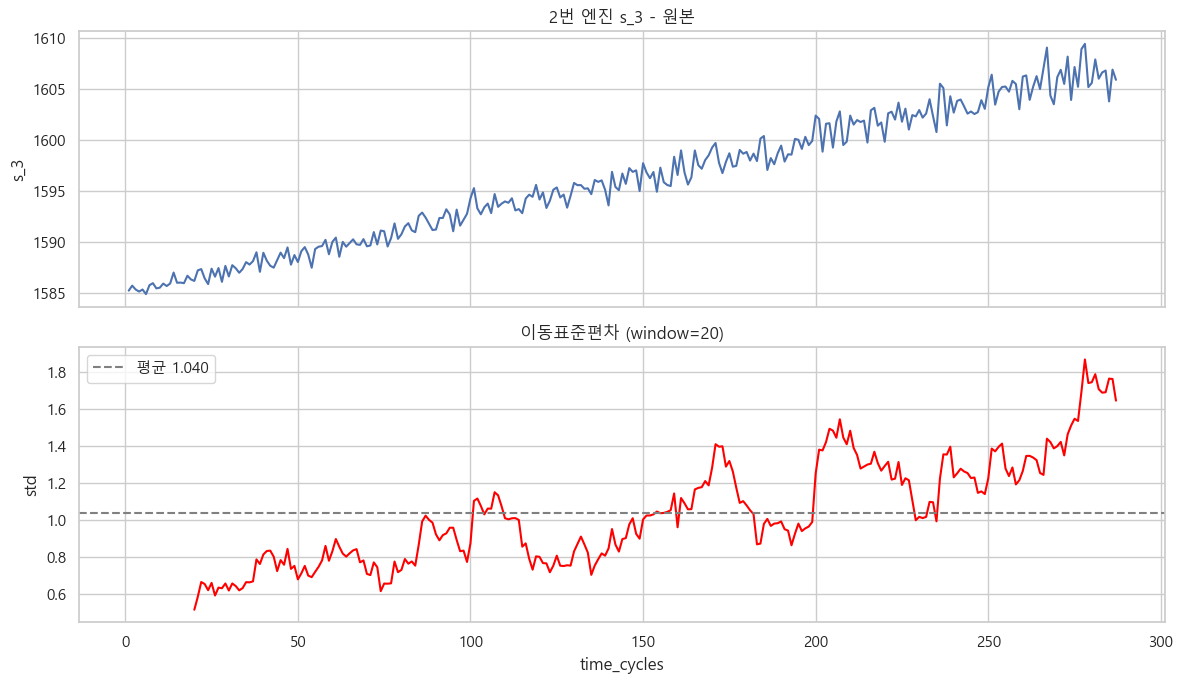


전반부 평균 변동성: 0.8085
후반부 평균 변동성: 1.2394  (+53.3%)
가장 흔들린 회차: 278 | 값 1.8675


In [6]:
df_5 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_5 = df_5[df_5["unit_nr"] == 2].sort_values("time_cycles")

# 창 크기 20으로 이동표준편차를 구하기
# 이동평균이 "어디쯤 있나"라면 이동표준편차는 "얼마나 흔들리나"를 본다
std20_5 = engine_5["s_3"].rolling(window=20).std()
print(std20_5.describe().round(4))

# 위칸에 원본, 아래칸에 이동표준편차를 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.set_title("2번 엔진 s_3 - 원본")
ax1.plot(engine_5["time_cycles"], engine_5["s_3"])
ax1.set_ylabel("s_3")

ax2.set_title("이동표준편차 (window=20)")
ax2.plot(engine_5["time_cycles"], std20_5, color="red")
ax2.axhline(y=std20_5.mean(), color="gray", linestyle="--", label=f"평균 {std20_5.mean():.3f}")
ax2.set_xlabel("time_cycles")
ax2.set_ylabel("std")
ax2.legend()

plt.tight_layout()
plt.show()

# 표준편차가 치솟는 구간을 변동성이 큰 구간으로 표시
# 전반부와 후반부를 갈라 평균을 비교하면 흔들림이 커졌는지 알 수 있다
n_5 = len(std20_5)
전반_5 = std20_5.iloc[: n_5 // 2].mean()
후반_5 = std20_5.iloc[n_5 // 2 :].mean()
print()
print(f"전반부 평균 변동성: {전반_5:.4f}")
print(f"후반부 평균 변동성: {후반_5:.4f}  ({(후반_5 / 전반_5 - 1) * 100:+.1f}%)")
print("가장 흔들린 회차:", engine_5["time_cycles"].iloc[std20_5.argmax()], "| 값", round(std20_5.max(), 4))

# [확인]
# 후반부 변동성이 전반부보다 약 53% 커졌다
# 값 자체가 오르는 것(추세)과 흔들림이 커지는 것(변동성)은 다른 신호다

---
## **실습 6 - 평균과 변동성 밴드 함께 그리기**
`이동평균선에 표준편차 두 배 띠를 둘러 정상 범위 보기`

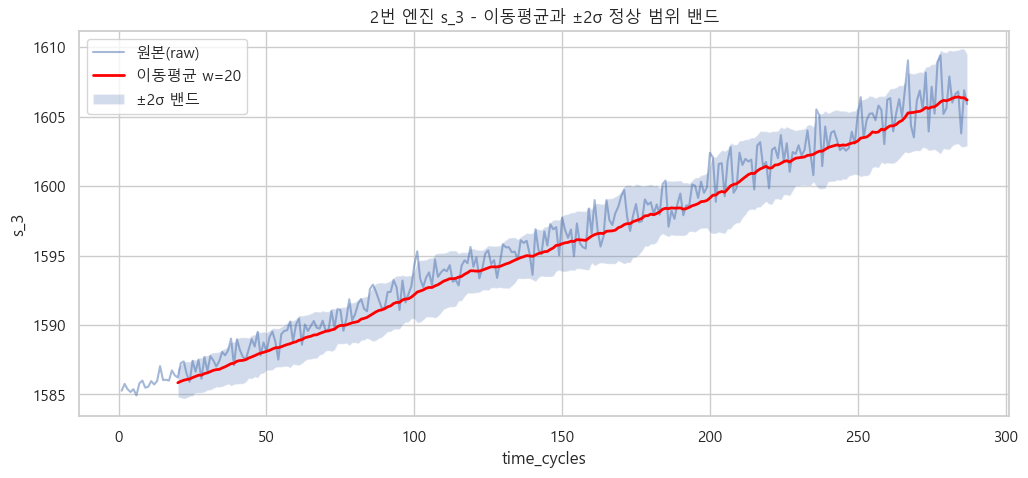

밴드 계산이 가능한 구간: 268 회차
밴드를 벗어난 점: 17 개 (6.3%)

[밴드를 벗어난 회차]
 time_cycles     s_3
          21 1587.25
          22 1587.38
          38 1589.02
          74 1591.15
          78 1591.85
          85 1592.59
          86 1592.91
         100 1594.30
         101 1595.30
         119 1595.62
         161 1598.99
         184 1600.15
         185 1600.40
         200 1602.40
         236 1605.52
         251 1606.40
         267 1609.05


In [7]:
df_6 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_6 = df_6[df_6["unit_nr"] == 2].sort_values("time_cycles")

# 창 크기 20으로 이동평균과 이동표준편차를 구하기
ma_6 = engine_6["s_3"].rolling(window=20).mean()
std_6 = engine_6["s_3"].rolling(window=20).std()

# 평균에 표준편차 두 배를 더하고 뺀 띠를 색으로 채우기
top_6 = ma_6 + 2 * std_6
bottom_6 = ma_6 - 2 * std_6

# 원본과 이동평균을 그리기
plt.figure(figsize=(12, 5))
plt.title("2번 엔진 s_3 - 이동평균과 ±2σ 정상 범위 밴드")
plt.plot(engine_6["time_cycles"], engine_6["s_3"], label="원본(raw)", alpha=0.5)
plt.plot(engine_6["time_cycles"], ma_6, label="이동평균 w=20", linewidth=2, color="red")
plt.fill_between(engine_6["time_cycles"], bottom_6, top_6, alpha=0.25, label="±2σ 밴드")
plt.xlabel("time_cycles")
plt.ylabel("s_3")
plt.legend()
plt.show()

# 밴드를 벗어난 점을 이상 후보로 세어보기
# 정규분포라면 ±2σ 밖은 약 5%가 정상 범위
밖_6 = (engine_6["s_3"] > top_6) | (engine_6["s_3"] < bottom_6)
유효_6 = ma_6.notna().sum()
print("밴드 계산이 가능한 구간:", 유효_6, "회차")
print("밴드를 벗어난 점:", 밖_6.sum(), f"개 ({밖_6.sum() / 유효_6 * 100:.1f}%)")
print()
print("[밴드를 벗어난 회차]")
print(engine_6.loc[밖_6, ["time_cycles", "s_3"]].to_string(index=False))

# [확인]
# 띠의 폭이 일정하지 않고 구간마다 넓어졌다 좁아진다 = 변동성이 시시각각 변한다는 뜻
# 이 밴드가 관리도(control chart)의 기본 아이디어다

---
## **실습 7 - 변동성 패턴 해석**
`여러 센서의 이동표준편차로 점증, 급증 패턴 비교`

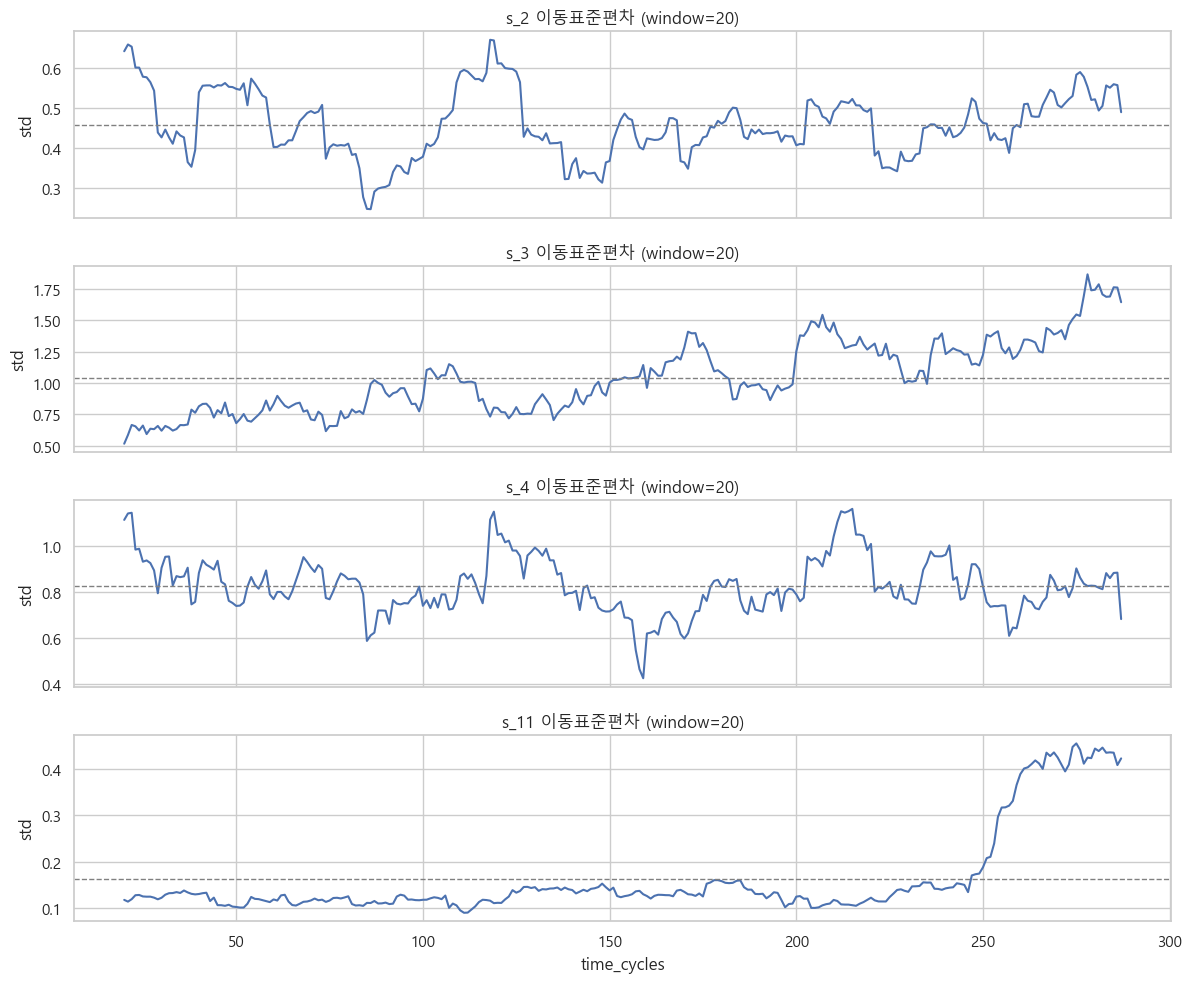

[센서별 변동성 패턴]
센서           전반부       후반부       증가율     최대/평균  패턴
------------------------------------------------------------
s_2       0.4644    0.4523     -2.6%      1.46  안정
s_3       0.8085    1.2394     53.3%      1.80  점증 (후반 불안정)
s_4       0.8535    0.8063     -5.5%      1.40  안정
s_11      0.1210    0.1995     64.9%      2.78  점증 (후반 불안정)


In [8]:
df_7 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
engine_7 = df_7[df_7["unit_nr"] == 2].sort_values("time_cycles")

sensors_7 = ["s_2", "s_3", "s_4", "s_11"]

# 대상 센서마다 창 크기 20 이동표준편차를 구해 센서별로 칸을 나눠 그리기
fig, axes = plt.subplots(len(sensors_7), 1, figsize=(12, 10), sharex=True)

for ax, sensor in zip(axes, sensors_7):
    std20_7 = engine_7[sensor].rolling(window=20).std()
    ax.plot(engine_7["time_cycles"], std20_7, label=sensor)
    ax.axhline(y=std20_7.mean(), color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{sensor} 이동표준편차 (window=20)")
    ax.set_ylabel("std")

axes[-1].set_xlabel("time_cycles")
plt.tight_layout()
plt.show()

# 서서히 커지는 점증과 갑자기 튀는 급증을 구분
# 전반부 대비 후반부 변동성 증가율로 점증 여부를 판정한다
print("[센서별 변동성 패턴]")
print(f"{'센서':<6}{'전반부':>10}{'후반부':>10}{'증가율':>10}{'최대/평균':>10}  패턴")
print("-" * 60)
for sensor in sensors_7:
    std20_7 = engine_7[sensor].rolling(window=20).std()
    n_7 = len(std20_7)
    전반_7 = std20_7.iloc[: n_7 // 2].mean()
    후반_7 = std20_7.iloc[n_7 // 2 :].mean()
    증가율_7 = (후반_7 / 전반_7 - 1) * 100
    첨도_7 = std20_7.max() / std20_7.mean()

    if 증가율_7 > 20:
        패턴_7 = "점증 (후반 불안정)"
    elif 첨도_7 > 2.0:
        패턴_7 = "급증 (특정 시점 튐)"
    else:
        패턴_7 = "안정"
    print(f"{sensor:<6}{전반_7:>10.4f}{후반_7:>10.4f}{증가율_7:>9.1f}%{첨도_7:>10.2f}  {패턴_7}")

# [최종 정리]
# 발견 : 2번 엔진 287회차에서 s_2/s_3/s_4/s_11은 상승, s_7은 하강으로 방향이 갈리지만
#        |r|이 전부 0.83 이상이라 다섯 센서 모두 뚜렷한 열화 추세를 담고 있다
# 해석 : 추세와 변동성은 별개 신호다. s_3은 후반 변동성이 약 53% 커져 점증 패턴을 보이는 반면,
#        s_4는 값은 계속 오르는데 변동성은 거의 그대로라 "조용히 밀리는" 형태다
# 행동 : 추세가 뚜렷한 센서는 RUL 예측 입력으로, 변동성이 점증하는 s_3은
#        ±2σ 밴드를 관리 기준으로 삼아 이탈 시점을 조기 경보로 쓰는 것이 다음 단계